#### Capstone Project Guideline
1. Define research questions
2. Load / Review the datasets
3. Data Cleaning and preparation
4. Exploratory data analysis
5. Feature Engineering
6. Statistical analysis and modelling (Baseline, Comparison Models)
7. Business Recommendations
8. Final Report

## 1.0 Introduction

Retail promotions such as coupons, discounts, and marketing campaigns are widely used to encourage customer purchases and increase sales. However, not all promotions generate the same level of customer spending, making it challenging for retailers to determine which promotional strategies provide the greatest return on investment.

This project aims to investigate the factors associated with higher customer spending during promotional campaigns. By analyzing customer purchasing behavior, product characteristics, household demographics, and promotional activities, the project seeks to identify the key drivers of customer spending. The findings can help retailers better target promotions, optimize marketing strategies, and make more informed pricing and inventory decisions.


## 2.0 Data Loading and Exploration

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [2]:
# Load the datasets
campaign_desc = pd.read_csv("data/campaign_desc.csv")
campaign_table = pd.read_csv("data/campaign_table.csv")
causal_data = pd.read_csv("data/causal_data.csv")
coupon_redempt = pd.read_csv("data/coupon_redempt.csv")
coupon = pd.read_csv("data/coupon.csv")
hh_demographic = pd.read_csv("data/hh_demographic.csv")
product = pd.read_csv("data/product.csv")
transaction_data = pd.read_csv("data/transaction_data.csv")

In [3]:
# Check the size of each dataset

datasets = {
    'Campaign Description': campaign_desc,
    'Campaign Table': campaign_table,
    'Causal Data': causal_data,
    'Coupon Redemption': coupon_redempt,
    'Coupon': coupon,
    'Household Demographics': hh_demographic,
    'Product': product,
    'Transaction Data': transaction_data
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Campaign Description: (30, 4)
Campaign Table: (7208, 3)
Causal Data: (36786524, 5)
Coupon Redemption: (2318, 4)
Coupon: (124548, 3)
Household Demographics: (801, 8)
Product: (92353, 7)
Transaction Data: (2595732, 12)


In [4]:
# Display the column names of each dataset

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.columns.tolist())


Campaign Description
['DESCRIPTION', 'CAMPAIGN', 'START_DAY', 'END_DAY']

Campaign Table
['DESCRIPTION', 'household_key', 'CAMPAIGN']

Causal Data
['PRODUCT_ID', 'STORE_ID', 'WEEK_NO', 'display', 'mailer']

Coupon Redemption
['household_key', 'DAY', 'COUPON_UPC', 'CAMPAIGN']

Coupon
['COUPON_UPC', 'PRODUCT_ID', 'CAMPAIGN']

Household Demographics
['AGE_DESC', 'MARITAL_STATUS_CODE', 'INCOME_DESC', 'HOMEOWNER_DESC', 'HH_COMP_DESC', 'HOUSEHOLD_SIZE_DESC', 'KID_CATEGORY_DESC', 'household_key']

Product
['PRODUCT_ID', 'MANUFACTURER', 'DEPARTMENT', 'BRAND', 'COMMODITY_DESC', 'SUB_COMMODITY_DESC', 'CURR_SIZE_OF_PRODUCT']

Transaction Data
['household_key', 'BASKET_ID', 'DAY', 'PRODUCT_ID', 'QUANTITY', 'SALES_VALUE', 'STORE_ID', 'RETAIL_DISC', 'TRANS_TIME', 'WEEK_NO', 'COUPON_DISC', 'COUPON_MATCH_DISC']


## 3.0 Data Cleaning
### 3.1 Check for Missing Rows

In [5]:
# Check data types and missing values

for name, df in datasets.items():
    print(f"\n{'='*40}")
    print(name)

    print("\nData types:")
    print(df.dtypes)

    print("\nMissing values:")
    print(df.isnull().sum())


Campaign Description

Data types:
DESCRIPTION    object
CAMPAIGN        int64
START_DAY       int64
END_DAY         int64
dtype: object

Missing values:
DESCRIPTION    0
CAMPAIGN       0
START_DAY      0
END_DAY        0
dtype: int64

Campaign Table

Data types:
DESCRIPTION      object
household_key     int64
CAMPAIGN          int64
dtype: object

Missing values:
DESCRIPTION      0
household_key    0
CAMPAIGN         0
dtype: int64

Causal Data

Data types:
PRODUCT_ID     int64
STORE_ID       int64
WEEK_NO        int64
display       object
mailer        object
dtype: object

Missing values:
PRODUCT_ID    0
STORE_ID      0
WEEK_NO       0
display       0
mailer        0
dtype: int64

Coupon Redemption

Data types:
household_key    int64
DAY              int64
COUPON_UPC       int64
CAMPAIGN         int64
dtype: object

Missing values:
household_key    0
DAY              0
COUPON_UPC       0
CAMPAIGN         0
dtype: int64

Coupon

Data types:
COUPON_UPC    int64
PRODUCT_ID    int64
CAM

### 3.2 Check for Duplicate Rows

In [6]:
# Check duplicate rows in each dataset

for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

Campaign Description: 0 duplicate rows
Campaign Table: 0 duplicate rows
Causal Data: 0 duplicate rows
Coupon Redemption: 0 duplicate rows
Coupon: 5164 duplicate rows
Household Demographics: 0 duplicate rows
Product: 0 duplicate rows
Transaction Data: 0 duplicate rows


### 3.2.1 Examine duplicate rows in Coupon Table

In [7]:
# Display some duplicate rows in the coupon dataset

coupon_duplicates = coupon[
    coupon.duplicated(keep=False)
]

display(coupon_duplicates.head(10))

,COUPON_UPC,PRODUCT_ID,CAMPAIGN
47,54100010032,34214,27
49,54100010032,34214,27
50,54100010032,34214,27
51,54100010032,34214,27
124,54589314175,48728,27
126,54589314175,48728,27
127,54589314187,48728,27
128,54589314187,48728,27
129,54589314187,48728,27
130,54589314187,48728,27


In [8]:
# Check unique values in the coupon dataset

print("Total rows:", len(coupon))
print("Unique coupon UPCs:", coupon['COUPON_UPC'].nunique())
print("Unique product IDs:", coupon['PRODUCT_ID'].nunique())
print("Unique campaigns:", coupon['CAMPAIGN'].nunique())

Total rows: 124548
Unique coupon UPCs: 1135
Unique product IDs: 44133
Unique campaigns: 30


Since these are exact duplicates, the repeated rows can be removed without losing unique coupon-product-campaign combinations.

In [9]:
# Remove exact duplicate rows from the coupon dataset

coupon_clean = coupon.drop_duplicates().copy()

# Compare before and after cleaning
print("Original rows:", len(coupon))
print("Rows after cleaning:", len(coupon_clean))
print("Duplicates remaining:", coupon_clean.duplicated().sum())

Original rows: 124548
Rows after cleaning: 119384
Duplicates remaining: 0


### 3.3 Outlier Analysis

In [10]:
# Summary statistics for transaction data

transaction_data[
    ['QUANTITY', 'SALES_VALUE', 'RETAIL_DISC',
     'COUPON_DISC', 'COUPON_MATCH_DISC']
].describe().round(2)

,QUANTITY,SALES_VALUE,RETAIL_DISC,COUPON_DISC,COUPON_MATCH_DISC
count,2595732.00,2595732.00,2595732.00,2595732.00,2595732.00
mean,100.43,3.10,-0.54,-0.02,-0.00
std,1153.44,4.18,1.25,0.22,0.04
min,0.00,0.00,-180.00,-55.93,-7.70
25%,1.00,1.29,-0.69,0.00,0.00
50%,1.00,2.00,-0.01,0.00,0.00
75%,1.00,3.49,0.00,0.00,0.00
max,89638.00,840.00,3.99,0.00,0.00


#### 3.3.1 Investigate Quantity and Sales column.
Quantity : Its mean is much higher than its median. That suggests some very large values are pulling the average upward. \
Sales_Value : Most transactions are worth just a few dollars, but at least one transaction is worth $840. That's a big difference. 

#### Quantity

In [11]:
# Inspect transactions with unusually large quantities
large_quantities = transaction_data[
    transaction_data['QUANTITY'] > 40000
]

large_quantities[
    ['household_key', 'BASKET_ID', 'PRODUCT_ID',
     'QUANTITY', 'SALES_VALUE']
].sort_values('QUANTITY', ascending=False).head(20)

,household_key,BASKET_ID,PRODUCT_ID,QUANTITY,SALES_VALUE
1750942,630,34749153595,6534178,89638,250.00
468356,2407,29392047893,6544236,85055,210.00
481876,630,29484790880,6534178,61335,150.21
166536,149,28210551971,6534178,51912,110.00
1340882,193,32956767959,6534178,48073,121.10
2472791,2133,41904760458,6534178,45475,100.00
1560340,149,33768630428,6534178,41833,115.00
376686,149,29035716247,6534178,41686,100.00
156049,1406,28167562655,6544236,41485,85.00


In [12]:
# Get the top 5 transactions by quantity
top_5 = large_quantities.nlargest(5, 'QUANTITY')

# Find their product details
product[
    product['PRODUCT_ID'].isin(top_5['PRODUCT_ID'])
][['PRODUCT_ID', 'DEPARTMENT', 'COMMODITY_DESC',
   'SUB_COMMODITY_DESC', 'CURR_SIZE_OF_PRODUCT']]

,PRODUCT_ID,DEPARTMENT,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
57221,6534178,KIOSK-GAS,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
57335,6544236,MISC SALES TRAN,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,


In [13]:
# Compare gasoline and non-gasoline transactions

gasoline_ids = [6534178, 6544236]

transaction_data['PRODUCT_TYPE'] = transaction_data[
    'PRODUCT_ID'
].apply(
    lambda x: 'Gasoline' if x in gasoline_ids else 'Other'
)

transaction_data.groupby('PRODUCT_TYPE')['QUANTITY'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
PRODUCT_TYPE,,,,,,,,
Gasoline,19956.0,10986.03,5205.42,10.0,7381.0,10596.0,14153.0,89638.0
Other,2575776.0,16.09,453.46,0.0,1.0,1.0,1.0,36140.0


In [14]:
#Check if there are any other gasoline related commodities.
product[
    product['SUB_COMMODITY_DESC'].str.contains(
        'GAS', case=False, na=False
    )
]['SUB_COMMODITY_DESC'].unique()

array(['GASOLINE-REG UNLEADED', 'RIGID GAS PERMEABLE',
       'GAS CANS AND FUNNELS', 'GAS GRILLS'], dtype=object)

In [15]:
#Check if those commodities are also skewing my data
gas_categories = [
    'RIGID GAS PERMEABLE',
    'GAS CANS AND FUNNELS',
    'GAS GRILLS'
]

gas_products = product[
    product['SUB_COMMODITY_DESC'].isin(gas_categories)
]

gas_check = transaction_data.merge(
    gas_products[['PRODUCT_ID', 'SUB_COMMODITY_DESC']],
    on='PRODUCT_ID',
    how='inner'
)

gas_check.groupby('SUB_COMMODITY_DESC').agg(
    transaction_count=('QUANTITY', 'size'),
    mean_quantity=('QUANTITY', 'mean'),
    median_quantity=('QUANTITY', 'median'),
    max_quantity=('QUANTITY', 'max')
).round(2)

,transaction_count,mean_quantity,median_quantity,max_quantity
SUB_COMMODITY_DESC,,,,
GAS CANS AND FUNNELS,25,1.04,1.0,2
GAS GRILLS,7,1.00,1.0,1
RIGID GAS PERMEABLE,109,1.04,1.0,2


Based on quantity, only regular unleaded gasoline would be excluded for now. The other three categories will stay.

In [16]:
#Create a clean transaction dataset

# Identify regular unleaded gasoline product IDs
gasoline_ids = product.loc[
    product['SUB_COMMODITY_DESC'] == 'GASOLINE-REG UNLEADED',
    'PRODUCT_ID'
].unique()

# Exclude gasoline transactions
transaction_clean = transaction_data[
    ~transaction_data['PRODUCT_ID'].isin(gasoline_ids)
].copy()

In [17]:
print("Original rows:", len(transaction_data))
print("Cleaned rows:", len(transaction_clean))
print("Rows removed:", len(transaction_data) - len(transaction_clean))

Original rows: 2595732
Cleaned rows: 2570770
Rows removed: 24962


In [18]:
transaction_clean[
    ['QUANTITY', 'SALES_VALUE', 'RETAIL_DISC',
     'COUPON_DISC', 'COUPON_MATCH_DISC']
].describe().round(2)

,QUANTITY,SALES_VALUE,RETAIL_DISC,COUPON_DISC,COUPON_MATCH_DISC
count,2570770.00,2570770.00,2570770.00,2570770.00,2570770.00
mean,1.30,2.89,-0.54,-0.02,-0.00
std,0.93,3.35,1.25,0.22,0.04
min,0.00,0.00,-180.00,-55.93,-7.70
25%,1.00,1.26,-0.66,0.00,0.00
50%,1.00,2.00,0.00,0.00,0.00
75%,1.00,3.39,0.00,0.00,0.00
max,144.00,840.00,3.99,0.00,0.00


### Sales_Values

In [19]:
# Calculate potential outliers using the IQR method

for column in ['SALES_VALUE']:
    Q1 = transaction_data[column].quantile(0.25)
    Q3 = transaction_data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = transaction_data[
        (transaction_data[column] < lower_bound) |
        (transaction_data[column] > upper_bound)
    ]

    print(column)
    print("Lower bound:", round(lower_bound, 2))
    print("Upper bound:", round(upper_bound, 2))
    print("Number of potential outliers:", len(outliers))
    print("Percentage of data:", round(len(outliers) / len(transaction_data) * 100, 2), "%")

SALES_VALUE
Lower bound: -2.01
Upper bound: 6.79
Number of potential outliers: 190644
Percentage of data: 7.34 %


In [20]:
#Inspect the largest transactions for Sales_Values
top_10_sales = transaction_data.nlargest(5, 'SALES_VALUE')[['PRODUCT_ID', 'QUANTITY', 'SALES_VALUE']]
top_10_sales

,PRODUCT_ID,QUANTITY,SALES_VALUE
1085442,12484608,3,840.00
2030766,948670,5,631.80
655985,1089093,2,505.00
1152895,13212959,1,499.99
547657,1089093,1,455.00


In [21]:
# Merge the top 10 sales transactions with product details
top_10_sales_products = top_10_sales.merge(
    product,
    on='PRODUCT_ID',
    how='left'
)

top_10_sales_products[
    ['PRODUCT_ID', 'QUANTITY', 'SALES_VALUE',
     'DEPARTMENT', 'COMMODITY_DESC',
     'SUB_COMMODITY_DESC']
]

,PRODUCT_ID,QUANTITY,SALES_VALUE,DEPARTMENT,COMMODITY_DESC,SUB_COMMODITY_DESC
0,12484608,3,840.00,MISC SALES TRAN,COUPON/MISC ITEMS,ELECTRONIC GIFT CARDS ACTIVATI
1,948670,5,631.80,DRUG GM,TICKETS,TICKETS
2,1089093,2,505.00,MISC. TRANS.,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION
3,13212959,1,499.99,DRUG GM,SPRING/SUMMER SEASONAL,OUTDOOR ROLL-UP BLINDS
4,1089093,1,455.00,MISC. TRANS.,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION


The IQR method identified potential outliers in SALES_VALUE. Inspection of the 10 highest-value transactions showed a mixture of products, including electronic gift cards, tickets, outdoor blinds and fruit baskets which is reasonable. Therefore, these transactions were retained.

### 3.4 Data Integration & Merging

In [22]:
# Check product ID uniqueness
print("Product rows:", len(product))
print("Unique product IDs:", product['PRODUCT_ID'].nunique())
print("Duplicate product IDs:", product['PRODUCT_ID'].duplicated().sum())

# Check household key uniqueness
print("Demographic rows:", len(hh_demographic))
print("Unique household keys:", hh_demographic['household_key'].nunique())
print("Duplicate household keys:", hh_demographic['household_key'].duplicated().sum())

Product rows: 92353
Unique product IDs: 92353
Duplicate product IDs: 0
Demographic rows: 801
Unique household keys: 801
Duplicate household keys: 0


#### 3.4.1 Merging Cleaned Transactions Table & Product Table

In [23]:
# Merge transactions with product details
transactions_merged = transaction_clean.merge(
    product,
    on='PRODUCT_ID',
    how='left',
    validate='many_to_one'
)

print("Original rows:", len(transaction_clean))
print("Merged rows:", len(transactions_merged))
print("Columns:", transactions_merged.shape[1])

Original rows: 2570770
Merged rows: 2570770
Columns: 19


#### 3.4.2 Merging Transactions_Product Table & Household Table

In [24]:
# Merge household demographics
transactions_merged = transactions_merged.merge(
    hh_demographic,
    on='household_key',
    how='left',
    validate='many_to_one'
)

print("Merged dataset shape:", transactions_merged.shape)

Merged dataset shape: (2570770, 26)


#### 3.4.3 Check the merge
Check whether any transactions are missing household demographic information.

In [25]:
# Check missing household demographics
transactions_merged['AGE_DESC'].isna().sum()

np.int64(1158239)

In [26]:
# Count transactions with and without demographic information
transactions_merged['AGE_DESC'].isna().value_counts()

AGE_DESC
False    1412531
True     1158239
Name: count, dtype: int64

In [27]:
# Percentage of transactions missing demographics
transactions_merged['AGE_DESC'].isna().mean() * 100

np.float64(45.05416665045881)

In [28]:
print("Households in transactions:",
      transaction_clean['household_key'].nunique())

print("Households in demographics:",
      hh_demographic['household_key'].nunique())

print("Households matched:",
      transactions_merged.loc[
          transactions_merged['AGE_DESC'].notna(),
          'household_key'
      ].nunique())

# Find households without demographic information
unmatched_households = transaction_clean.loc[
    ~transaction_clean['household_key'].isin(
        hh_demographic['household_key']
    ),
    'household_key'
].nunique()

print("Unmatched households:", unmatched_households)

Households in transactions: 2500
Households in demographics: 801
Households matched: 801
Unmatched households: 1699


### Summary 
The transaction data was successfully merged with the product and household demographic tables using a left join. The merged dataset retained all 2,570,770 transaction records, with no additional rows created during the merge.

Out of 2,500 unique households in the transaction data, 801 had matching demographic information. The remaining 1,699 households were not present in the demographic dataset. Consequently, 1,158,239 transactions (45.05%) have missing demographic values.

The missing demographic information will not be removed, as these transactions are still useful for analyzing overall spending and product purchasing behavior. However, demographic analyses will be limited to transactions with available demographic information.

### 4.0 Exploratory Data Analysis
#### 4.1 Sales by Product Category

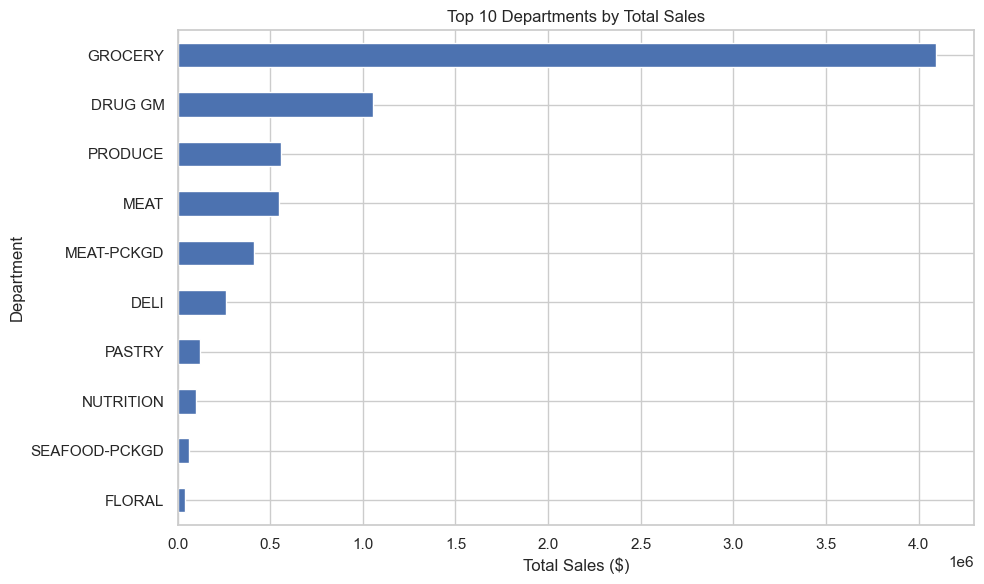

In [29]:
# Calculate total sales by department
department_sales = (
    transactions_merged.groupby('DEPARTMENT')['SALES_VALUE']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Create bar chart
department_sales.sort_values().plot(
    kind='barh',
    figsize=(10, 6)
)

plt.title('Top 10 Departments by Total Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Department')
plt.tight_layout()
plt.show()

The analysis of total sales by department shows that Grocery generates the highest sales, followed by Drug GM. Produce and Meat also contribute substantially to total sales, while the remaining departments have comparatively lower sales. This provides an overview of the distribution of sales across departments and helps identify the product categories that contribute most to revenue.

#### 4.2 Distribution of Transaction Sales Values

In [30]:
transactions_merged['SALES_VALUE'].describe().round(2)

count    2570770.00
mean           2.89
std            3.35
min            0.00
25%            1.26
50%            2.00
75%            3.39
max          840.00
Name: SALES_VALUE, dtype: float64

The descriptive statistics show that the average sales value per transaction record is \\$2.89, while the median is \\$2.00. Since the mean is higher than the median, the distribution appears to be right-skewed. Additionally, 75% of transaction records have sales values of \\$3.39 or less. The maximum value of \\$840 is substantially higher than the typical sales value, suggesting the presence of high-value observations that may warrant further investigation.

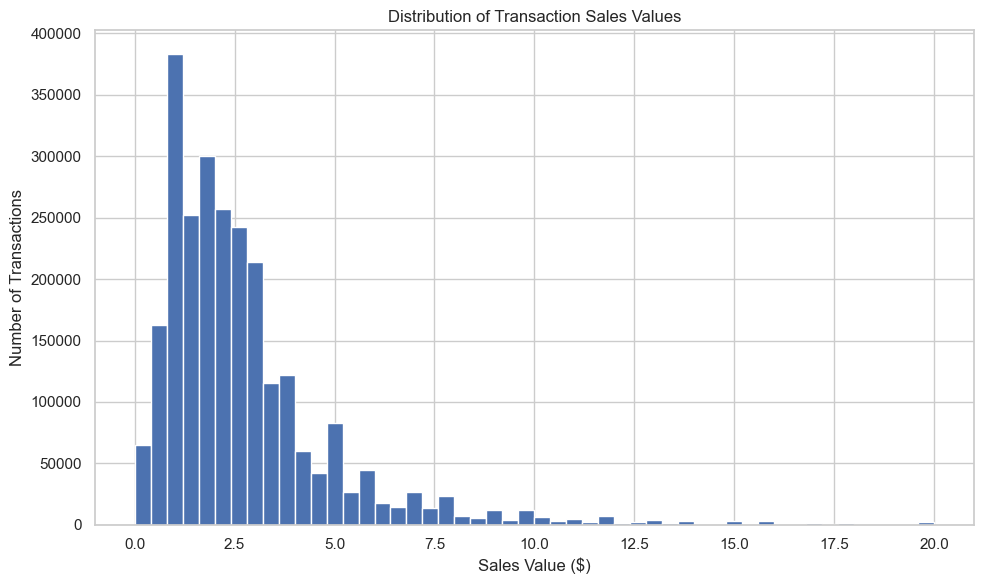

In [31]:
plt.figure(figsize=(10, 6))

plt.hist(
    transactions_merged['SALES_VALUE'],
    bins=50,
    range=(0, 20)
)

plt.title('Distribution of Transaction Sales Values')
plt.xlabel('Sales Value ($)')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

The histogram shows a right-skewed distribution of transaction sales values. Most records are concentrated between \\$1 and \\$3, while the frequency of transactions generally decreases as sales values increase. A small number of transactions have substantially higher sales values, resulting in a long right tail. This pattern is consistent with the difference between the mean and median observed in the descriptive statistics.

#### 4.3 Customer Level Spending Pattern

In [32]:
household_spending = (
    transactions_merged
    .groupby('household_key')['SALES_VALUE']
    .sum()
)

household_spending.describe().round(2)

count     2500.00
mean      2969.40
std       2987.77
min          8.17
25%        920.96
50%       2051.72
75%       4037.96
max      26984.95
Name: SALES_VALUE, dtype: float64

The analysis of household spending shows that the average household spent \\$2,969.40, while the median spending was \\$2,051.72. The mean being higher than the median suggests a right-skewed distribution, with some households spending considerably more than others. The wide range of spending values indicates substantial variation in customer spending behavior. These differences may be useful for identifying customer segments with different spending patterns.

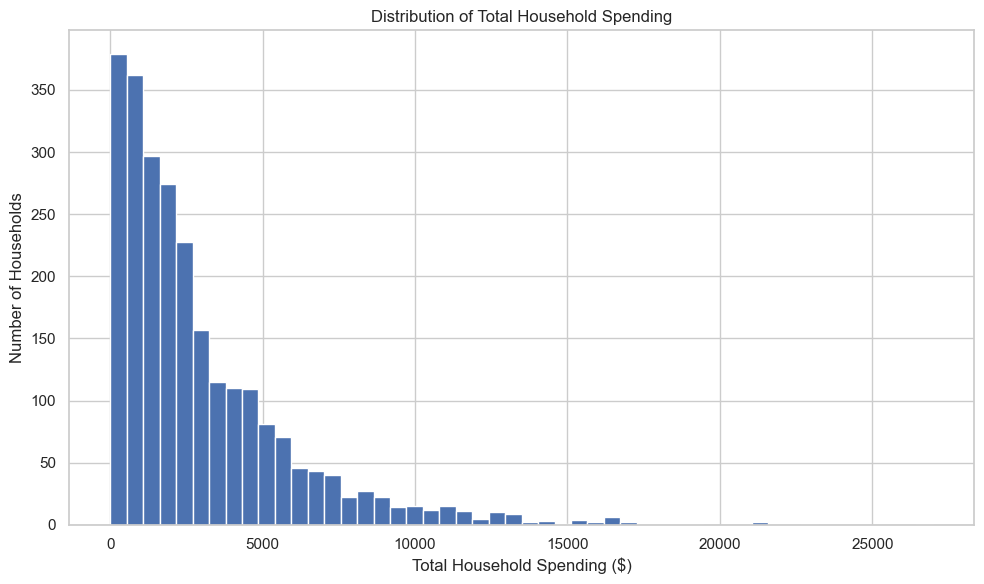

In [33]:
plt.figure(figsize=(10, 6))

plt.hist(household_spending, bins=50)

plt.title('Distribution of Total Household Spending')
plt.xlabel('Total Household Spending ($)')
plt.ylabel('Number of Households')
plt.tight_layout()
plt.show()

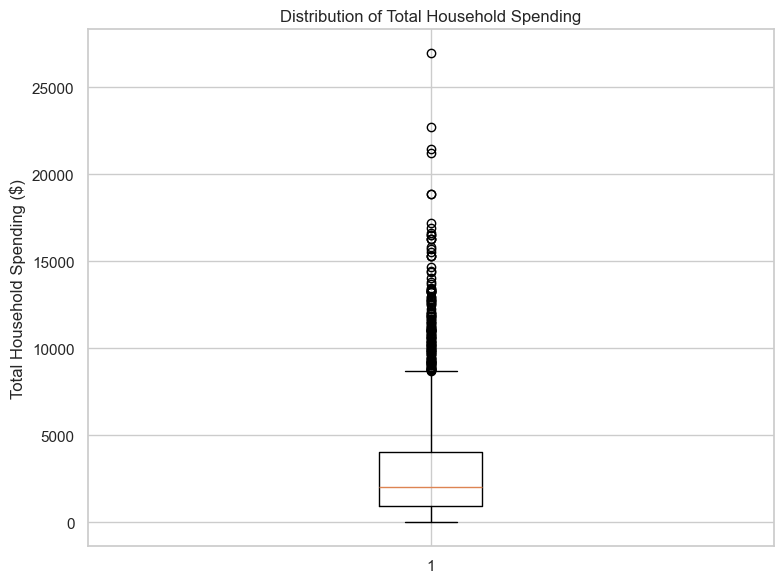

In [34]:
plt.figure(figsize=(8, 6))

plt.boxplot(household_spending, vert=True)

plt.title('Distribution of Total Household Spending')
plt.ylabel('Total Household Spending ($)')
plt.tight_layout()
plt.show()

The box plot shows a right-skewed distribution of household spending, with a median of \\$2,051.72. Most households have spending values within the interquartile range of \\$920.96 to \\$4,037.96. There are numerous potential outliers above the upper whisker, indicating that some households spent substantially more than the majority. These high-spending observations will be retained because they may represent genuine customer behavior rather than data errors.

#### 4.4 Shopping frequency versus Total Household Spending.

In [35]:
household_frequency = (
    transactions_merged
    .groupby('household_key')['BASKET_ID']
    .nunique()
)

household_analysis = pd.DataFrame({
    'Total_Spending': household_spending,
    'Shopping_Frequency': household_frequency
})

household_analysis.head()

,Total_Spending,Shopping_Frequency
household_key,,
1,4330.16,86
2,1954.34,45
3,2633.20,46
4,1200.11,30
5,779.06,40


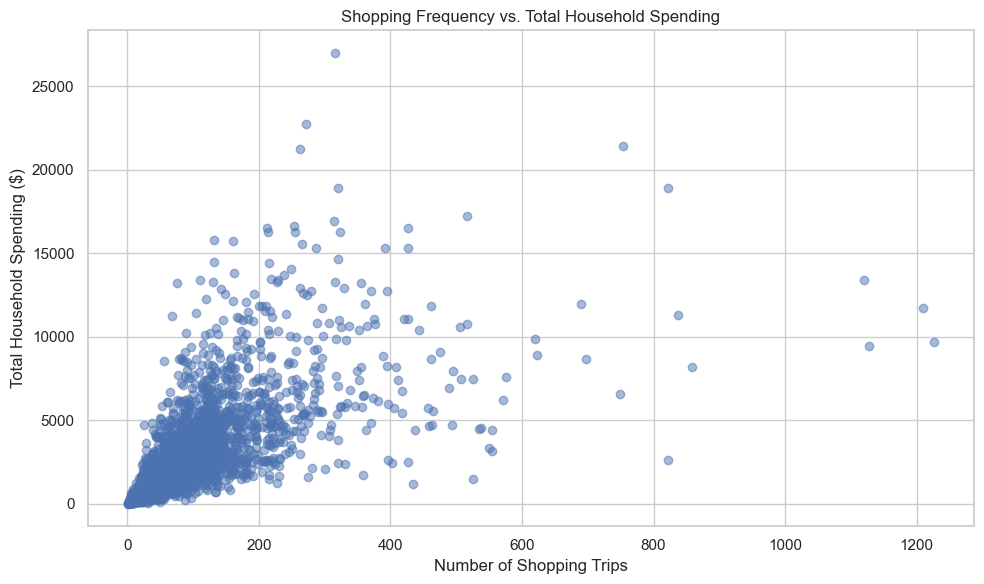

In [36]:
plt.figure(figsize=(10, 6))

plt.scatter(
    household_analysis['Shopping_Frequency'],
    household_analysis['Total_Spending'],
    alpha=0.5
)

plt.title('Shopping Frequency vs. Total Household Spending')
plt.xlabel('Number of Shopping Trips')
plt.ylabel('Total Household Spending ($)')
plt.tight_layout()
plt.show()

The scatter plot shows a positive association between shopping frequency and total household spending. Households with more shopping trips generally tend to have higher total spending. However, there is considerable variation in spending among households with similar shopping frequencies, suggesting that shopping frequency alone does not explain customer spending behavior. A few households have exceptionally high shopping frequencies, creating extreme values in the dataset.

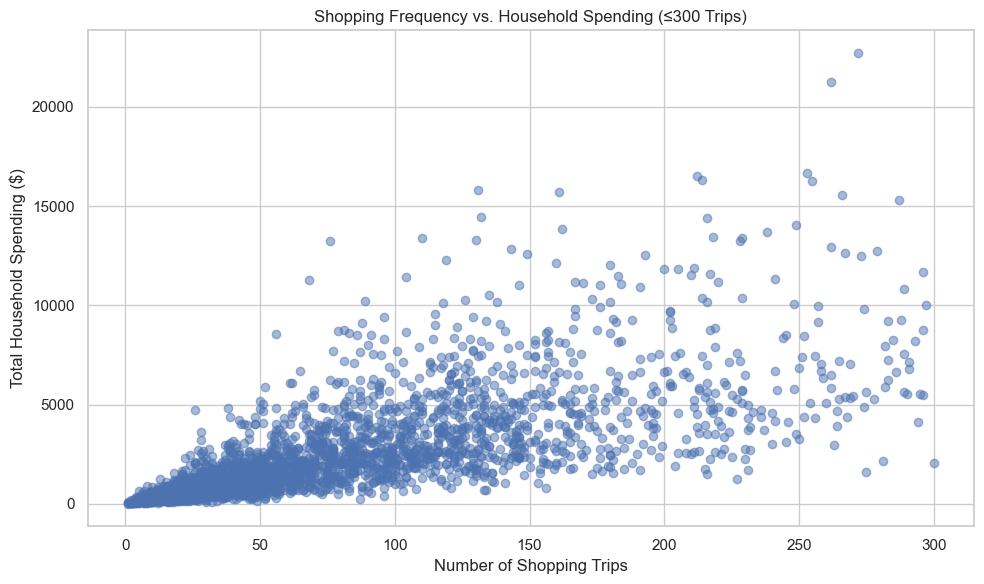

In [37]:
plt.figure(figsize=(10, 6))

plt.scatter(
    household_analysis.loc[
        household_analysis['Shopping_Frequency'] <= 300,
        'Shopping_Frequency'
    ],
    household_analysis.loc[
        household_analysis['Shopping_Frequency'] <= 300,
        'Total_Spending'
    ],
    alpha=0.5
)

plt.title('Shopping Frequency vs. Household Spending (≤300 Trips)')
plt.xlabel('Number of Shopping Trips')
plt.ylabel('Total Household Spending ($)')
plt.tight_layout()
plt.show()

The scatter plot shows a positive association between shopping frequency and total household spending. However, considerable variation exists among households with similar shopping frequencies. This suggests that shopping frequency is related to spending, but other factors may also influence household spending behavior. The visualization is limited to households with 300 or fewer shopping trips to make the main pattern easier to observe.

#### 4.5 Correlation between shopping frequency and total household spending.

In [38]:
household_analysis[
    ['Shopping_Frequency', 'Total_Spending']
].corr()

,Shopping_Frequency,Total_Spending
Shopping_Frequency,1.000000,0.650849
Total_Spending,0.650849,1.000000


The Pearson correlation coefficient between shopping frequency and total household spending is 0.651, indicating a moderately strong positive linear relationship. This suggests that households with more shopping trips generally tend to have higher total spending. However, correlation does not imply causation, and other factors may also influence household spending behavior.

#### 4.6 Promotional Effectiveness

In [39]:
redeemed_households = coupon_redempt['household_key'].unique()

household_analysis['Redeemed_Coupon'] = (
    household_analysis.index.isin(redeemed_households)
)

household_analysis['Redeemed_Coupon'].value_counts()

Redeemed_Coupon
False    2066
True      434
Name: count, dtype: int64

In [40]:
#Compare spending between the two groups
household_analysis.groupby('Redeemed_Coupon')[
    'Total_Spending'
].agg(['count', 'mean', 'median']).round(2)

,count,mean,median
Redeemed_Coupon,,,
False,2066,2340.89,1662.32
True,434,5961.34,5105.00


The analysis shows that households that redeemed coupons had higher average spending (\\$5,961.34) than households that did not redeem coupons (\\$2,340.89). The median spending was also higher among coupon-redeeming households (\\$5,105.00) compared with non-redeeming households (\\$1,662.32). These results indicate an association between coupon redemption and higher household spending. However, this does not establish that coupon redemption caused higher spending, as other factors, such as shopping frequency and existing spending habits, may contribute to the difference.

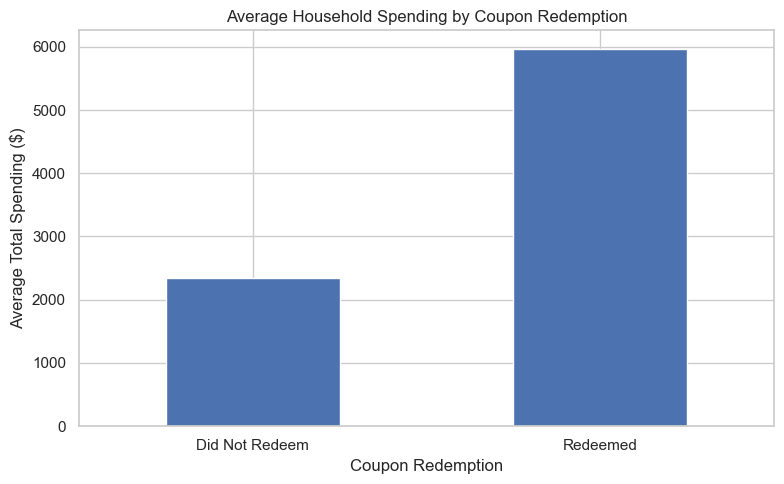

In [41]:
avg_spending = household_analysis.groupby(
    'Redeemed_Coupon'
)['Total_Spending'].mean()

avg_spending.index = [
    'Did Not Redeem',
    'Redeemed'
]

avg_spending.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Household Spending by Coupon Redemption')
plt.xlabel('Coupon Redemption')
plt.ylabel('Average Total Spending ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The bar chart shows that households that redeemed coupons had substantially higher average spending (\\$5,961.34) than households that did not redeem coupons (\\$2,340.89). Coupon-redeeming households spent approximately 2.55 times more on average. This suggests an association between coupon redemption and household spending. However, the difference does not establish that coupons caused higher spending, as other factors, such as shopping frequency and existing purchasing habits, may contribute.

In [42]:
#Compare the shopping frequency of the two groups.
household_analysis.groupby('Redeemed_Coupon')[
    'Shopping_Frequency'
].agg(['mean', 'median']).round(2)

,mean,median
Redeemed_Coupon,,
False,86.60,60.0
True,169.65,133.5


The analysis shows that households that redeemed coupons had a higher average shopping frequency (169.65 trips) than households that did not redeem coupons (86.60 trips). The median shopping frequency was also higher among coupon-redeeming households (133.5 trips) compared with non-redeeming households (60 trips). This suggests that coupon redemption is associated with more frequent shopping. The higher shopping frequency may partly explain the difference in total household spending between the two groups. However, this analysis does not establish a causal relationship.

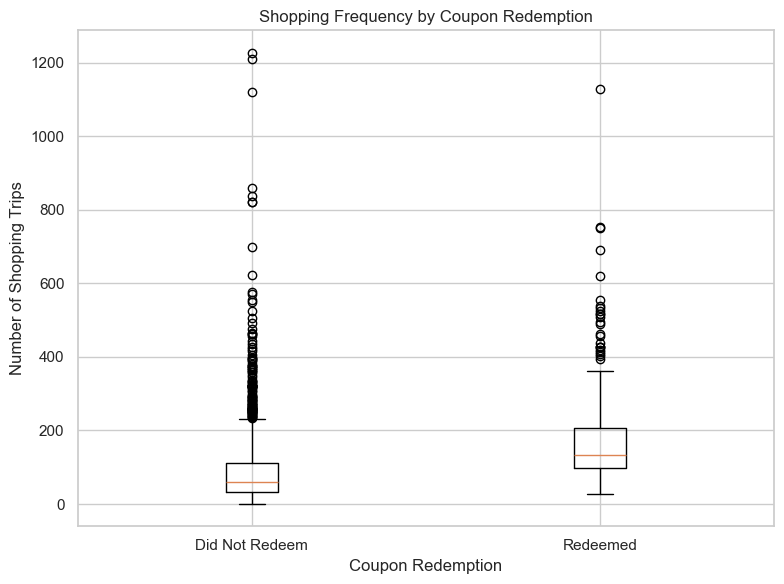

In [43]:
plt.figure(figsize=(8, 6))

data = [
    household_analysis.loc[
        household_analysis['Redeemed_Coupon'] == False,
        'Shopping_Frequency'
    ],
    household_analysis.loc[
        household_analysis['Redeemed_Coupon'] == True,
        'Shopping_Frequency'
    ]
]

plt.boxplot(data, tick_labels=['Did Not Redeem', 'Redeemed'])

plt.title('Shopping Frequency by Coupon Redemption')
plt.xlabel('Coupon Redemption')
plt.ylabel('Number of Shopping Trips')
plt.tight_layout()
plt.show()

The box plot shows that households that redeemed coupons generally had a higher shopping frequency than households that did not. The median shopping frequency was approximately 134 trips for coupon-redeeming households, compared with 60 trips for non-redeeming households. Both groups contain numerous outliers, indicating considerable variation in shopping frequency. This suggests an association between coupon redemption and shopping frequency, although it does not establish that coupon use caused households to shop more often.

#### 4.7 Coupon redemption by household income

In [44]:
# Combine household spending and coupon redemption
# with demographic information
demographic_analysis = (
    household_analysis.reset_index()
    .merge(hh_demographic, on='household_key', how='inner')
)

# Calculate coupon redemption rate by income
income_redemption = (
    demographic_analysis.groupby('INCOME_DESC')['Redeemed_Coupon']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

income_redemption

INCOME_DESC
150-174K     63.333333
125-149K     52.631579
50-74K       46.354167
175-199K     45.454545
100-124K     41.176471
25-34K       36.363636
Under 15K    36.065574
75-99K       35.416667
35-49K       34.302326
15-24K       24.324324
200-249K     20.000000
250K+        18.181818
Name: Redeemed_Coupon, dtype: float64

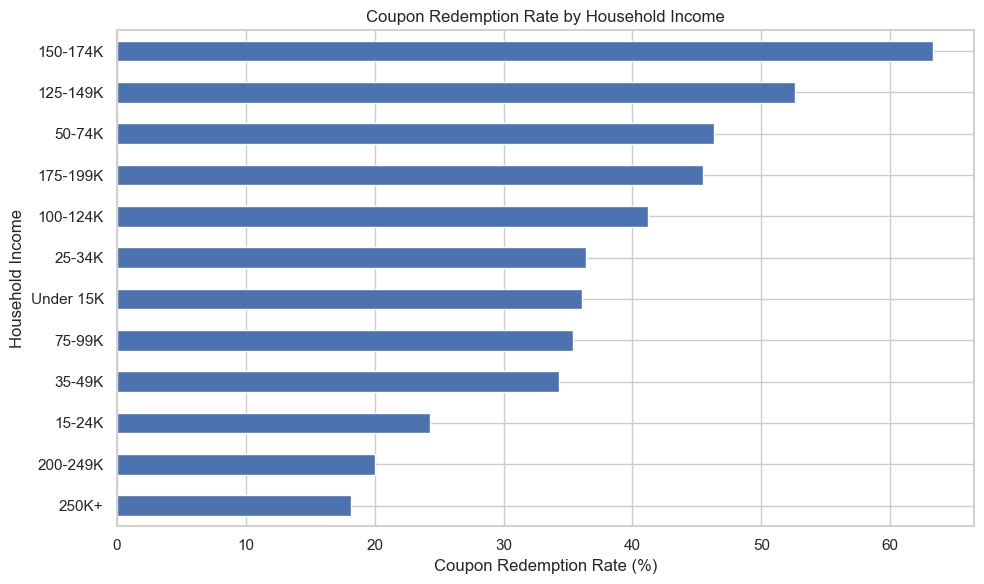

In [45]:
plt.figure(figsize=(10, 6))

income_redemption.sort_values().plot(kind='barh')

plt.title('Coupon Redemption Rate by Household Income')
plt.xlabel('Coupon Redemption Rate (%)')
plt.ylabel('Household Income')
plt.tight_layout()
plt.show()

Coupon redemption rates vary across household income groups. The $150K–$174K group has the highest redemption rate, while the $250K+ group has the lowest. This suggests that coupon redemption behavior differs across income categories. However, the results show an association rather than a causal relationship. Differences in the number of households in each income group may also affect the reliability of these rates.

### Summary

The exploratory data analysis examined transaction-level sales, household spending, shopping frequency, and coupon redemption to understand customer purchasing behavior and promotional engagement.

The distribution of transaction sales values was strongly right-skewed. Most transactions had relatively low sales values, with a median of \\$2.00 and a mean of \\$2.89. A small number of transactions had substantially higher values, including a maximum of $840. These high-value transactions were retained because they may represent legitimate purchases.

At the household level, total spending was also right-skewed. Across 2,500 households, average total spending was \\$2,969.40, while the median was \\$2,051.72. This indicates that spending varied considerably between households, with some customers contributing substantially more to total sales than others.

Shopping frequency was positively correlated with total household spending, with a Pearson correlation coefficient of 0.65. The scatter plot showed that households with more shopping trips generally tended to spend more. However, the relationship was not perfect, suggesting that shopping frequency alone does not explain differences in household spending.

Coupon redemption analysis showed that 434 of the 2,500 households redeemed coupons, while 2,066 did not. Households that redeemed coupons had higher average total spending (\\$5,961.34) and median spending (\\$5,105.00) than households that did not redeem coupons, whose average and median spending were \\$2,340.89 and \\$1,662.32, respectively. They also had higher shopping frequency, with a median of approximately 134 trips compared with 60 trips among non-redeeming households.

Coupon redemption rates also varied across household income categories. The \\$150K–\\$174K income group had the highest observed redemption rate, at approximately 63%, while the $250K+ group had the lowest, at approximately 17%. This suggests differences in coupon engagement across income groups, although the number of households in each group should be considered when interpreting these rates.

The department-level sales analysis provided an additional view of purchasing behavior by showing how total sales were distributed across product departments.

Overall, the analysis suggests that household spending is associated with shopping frequency and that households redeeming coupons tend to have higher spending and shopping frequency. Coupon redemption also varies across income groups. These findings provide useful context for customer segmentation and promotional analysis. However, the observed relationships are associations and do not establish that coupon redemption causes higher spending or more frequent shopping.

## 5.0 Feature Engineering
#### 5.1 Create customer spending features
**Average basket value**

In [46]:
household_analysis['Avg_Basket_Value'] = (
    household_analysis['Total_Spending'] /
    household_analysis['Shopping_Frequency']
)

household_analysis.head()

,Total_Spending,Shopping_Frequency,Redeemed_Coupon,Avg_Basket_Value
household_key,,,,
1,4330.16,86,True,50.350698
2,1954.34,45,False,43.429778
3,2633.20,46,False,57.243478
4,1200.11,30,False,40.003667
5,779.06,40,False,19.476500


In [47]:
household_analysis['Avg_Basket_Value'].describe().round(2)

count    2500.00
mean       32.29
std        20.22
min         2.39
25%        18.16
50%        27.72
75%        41.39
max       181.97
Name: Avg_Basket_Value, dtype: float64

**Average Quantity per trip**

In [48]:
household_analysis['Avg_Quantity_Per_Basket'] = (
    transactions_merged.groupby('household_key')['QUANTITY'].sum() /
    household_analysis['Shopping_Frequency']
)

household_analysis.head()

,Total_Spending,Shopping_Frequency,Redeemed_Coupon,Avg_Basket_Value,Avg_Quantity_Per_Basket
household_key,,,,,
1,4330.16,86,True,50.350698,23.220930
2,1954.34,45,False,43.429778,18.533333
3,2633.20,46,False,57.243478,34.586957
4,1200.11,30,False,40.003667,12.733333
5,779.06,40,False,19.476500,6.125000


In [49]:
household_analysis['Avg_Quantity_Per_Basket'].describe().round(2)

count    2500.00
mean       14.49
std         8.62
min         1.59
25%         8.30
50%        12.67
75%        18.43
max        79.79
Name: Avg_Quantity_Per_Basket, dtype: float64

#### 5.2 Create product preference features
**Department Spending**

In [50]:
department_spending = transactions_merged.pivot_table(
    index='household_key',
    columns='DEPARTMENT',
    values='SALES_VALUE',
    aggfunc='sum',
    fill_value=0
)

department_spending.head()

DEPARTMENT,,AUTOMOTIVE,CHARITABLE CONT,CHEF SHOPPE,CNTRL/STORE SUP,COSMETICS,COUP/STR & MFG,DAIRY DELI,DELI,DELI/SNACK BAR,DRUG GM,ELECT &PLUMBING,FLORAL,FROZEN GROCERY,GARDEN CENTER,GM MERCH EXP,GRO BAKERY,GROCERY,HBC,HOUSEWARES,MEAT,MEAT-PCKGD,MEAT-WHSE,MISC SALES TRAN,MISC. TRANS.,NUTRITION,PASTRY,PHARMACY SUPPLY,PHOTO,PORK,POSTAL CENTER,PROD-WHS SALES,PRODUCE,RESTAURANT,RX,SALAD BAR,SEAFOOD,SEAFOOD-PCKGD,SPIRITS,TOYS,TRAVEL & LEISUR,VIDEO,VIDEO RENTAL
household_key,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,212.17,0.0,530.89,0.0,7.99,0.0,0.0,0.0,0.0,2755.00,0.0,0.0,17.91,331.09,0.0,20.00,0.0,48.33,95.31,0.0,0.0,0.0,0.0,0.0,266.10,4.17,0.0,41.20,0.0,0.00,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,22.07,0.0,0.0,46.73,0.0,330.04,0.0,21.99,0.0,0.0,0.0,0.0,1112.49,0.0,0.0,154.32,68.88,0.0,4.26,0.0,7.47,24.82,0.0,0.0,0.0,0.0,0.0,152.28,0.00,0.0,0.00,0.0,8.99,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.25,0.0,0.0,36.47,0.0,159.08,0.0,0.00,0.0,0.0,0.0,0.0,1784.75,0.0,0.0,317.27,251.72,0.0,0.00,0.0,0.00,3.29,0.0,0.0,0.0,0.0,0.0,68.03,0.00,0.0,1.36,0.0,9.98,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,2.12,0.0,0.0,14.35,0.0,318.98,0.0,0.00,0.0,0.0,0.0,0.0,698.73,0.0,0.0,38.74,105.66,0.0,0.00,0.0,3.29,0.00,0.0,0.0,0.0,0.0,0.0,4.87,0.00,0.0,0.00,0.0,13.37,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,9.48,0.0,0.0,80.03,0.0,203.08,0.0,0.00,0.0,0.0,0.0,0.0,359.13,0.0,0.0,49.75,71.02,0.0,0.00,0.0,2.00,2.38,0.0,0.0,0.0,0.0,0.0,2.19,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0


In [51]:
department_spending.shape

(2500, 43)

In [52]:
household_features = household_analysis.join(department_spending)

household_features.head()

,Total_Spending,Shopping_Frequency,Redeemed_Coupon,Avg_Basket_Value,Avg_Quantity_Per_Basket,,AUTOMOTIVE,CHARITABLE CONT,CHEF SHOPPE,CNTRL/STORE SUP,COSMETICS,COUP/STR & MFG,DAIRY DELI,DELI,DELI/SNACK BAR,DRUG GM,ELECT &PLUMBING,FLORAL,FROZEN GROCERY,GARDEN CENTER,GM MERCH EXP,GRO BAKERY,GROCERY,HBC,HOUSEWARES,MEAT,MEAT-PCKGD,MEAT-WHSE,MISC SALES TRAN,MISC. TRANS.,NUTRITION,PASTRY,PHARMACY SUPPLY,PHOTO,PORK,POSTAL CENTER,PROD-WHS SALES,PRODUCE,RESTAURANT,RX,SALAD BAR,SEAFOOD,SEAFOOD-PCKGD,SPIRITS,TOYS,TRAVEL & LEISUR,VIDEO,VIDEO RENTAL
household_key,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,4330.16,86,True,50.350698,23.220930,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,212.17,0.0,530.89,0.0,7.99,0.0,0.0,0.0,0.0,2755.00,0.0,0.0,17.91,331.09,0.0,20.00,0.0,48.33,95.31,0.0,0.0,0.0,0.0,0.0,266.10,4.17,0.0,41.20,0.0,0.00,0.0,0.0,0.0,0.0,0.0
2,1954.34,45,False,43.429778,18.533333,0.0,0.0,0.0,0.0,0.0,22.07,0.0,0.0,46.73,0.0,330.04,0.0,21.99,0.0,0.0,0.0,0.0,1112.49,0.0,0.0,154.32,68.88,0.0,4.26,0.0,7.47,24.82,0.0,0.0,0.0,0.0,0.0,152.28,0.00,0.0,0.00,0.0,8.99,0.0,0.0,0.0,0.0,0.0
3,2633.20,46,False,57.243478,34.586957,0.0,0.0,0.0,0.0,0.0,1.25,0.0,0.0,36.47,0.0,159.08,0.0,0.00,0.0,0.0,0.0,0.0,1784.75,0.0,0.0,317.27,251.72,0.0,0.00,0.0,0.00,3.29,0.0,0.0,0.0,0.0,0.0,68.03,0.00,0.0,1.36,0.0,9.98,0.0,0.0,0.0,0.0,0.0
4,1200.11,30,False,40.003667,12.733333,0.0,0.0,0.0,0.0,0.0,2.12,0.0,0.0,14.35,0.0,318.98,0.0,0.00,0.0,0.0,0.0,0.0,698.73,0.0,0.0,38.74,105.66,0.0,0.00,0.0,3.29,0.00,0.0,0.0,0.0,0.0,0.0,4.87,0.00,0.0,0.00,0.0,13.37,0.0,0.0,0.0,0.0,0.0
5,779.06,40,False,19.476500,6.125000,0.0,0.0,0.0,0.0,0.0,9.48,0.0,0.0,80.03,0.0,203.08,0.0,0.00,0.0,0.0,0.0,0.0,359.13,0.0,0.0,49.75,71.02,0.0,0.00,0.0,2.00,2.38,0.0,0.0,0.0,0.0,0.0,2.19,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0


In [53]:
household_features.shape

(2500, 48)

In [54]:
household_features.isnull().sum().sum()

np.int64(0)

#### 5.3 Create coupon behavior features
**Coupon Redemption Count**

In [55]:
coupon_counts = coupon_redempt.groupby('household_key').size()

household_features['Coupon_Redemption_Count'] = (
    coupon_counts.reindex(household_features.index, fill_value=0)
)

household_features.head()

,Total_Spending,Shopping_Frequency,Redeemed_Coupon,Avg_Basket_Value,Avg_Quantity_Per_Basket,,AUTOMOTIVE,CHARITABLE CONT,CHEF SHOPPE,CNTRL/STORE SUP,COSMETICS,COUP/STR & MFG,DAIRY DELI,DELI,DELI/SNACK BAR,DRUG GM,ELECT &PLUMBING,FLORAL,FROZEN GROCERY,GARDEN CENTER,GM MERCH EXP,GRO BAKERY,GROCERY,HBC,HOUSEWARES,MEAT,MEAT-PCKGD,MEAT-WHSE,MISC SALES TRAN,MISC. TRANS.,NUTRITION,PASTRY,PHARMACY SUPPLY,PHOTO,PORK,POSTAL CENTER,PROD-WHS SALES,PRODUCE,RESTAURANT,RX,SALAD BAR,SEAFOOD,SEAFOOD-PCKGD,SPIRITS,TOYS,TRAVEL & LEISUR,VIDEO,VIDEO RENTAL,Coupon_Redemption_Count
household_key,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,4330.16,86,True,50.350698,23.220930,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,212.17,0.0,530.89,0.0,7.99,0.0,0.0,0.0,0.0,2755.00,0.0,0.0,17.91,331.09,0.0,20.00,0.0,48.33,95.31,0.0,0.0,0.0,0.0,0.0,266.10,4.17,0.0,41.20,0.0,0.00,0.0,0.0,0.0,0.0,0.0,5
2,1954.34,45,False,43.429778,18.533333,0.0,0.0,0.0,0.0,0.0,22.07,0.0,0.0,46.73,0.0,330.04,0.0,21.99,0.0,0.0,0.0,0.0,1112.49,0.0,0.0,154.32,68.88,0.0,4.26,0.0,7.47,24.82,0.0,0.0,0.0,0.0,0.0,152.28,0.00,0.0,0.00,0.0,8.99,0.0,0.0,0.0,0.0,0.0,0
3,2633.20,46,False,57.243478,34.586957,0.0,0.0,0.0,0.0,0.0,1.25,0.0,0.0,36.47,0.0,159.08,0.0,0.00,0.0,0.0,0.0,0.0,1784.75,0.0,0.0,317.27,251.72,0.0,0.00,0.0,0.00,3.29,0.0,0.0,0.0,0.0,0.0,68.03,0.00,0.0,1.36,0.0,9.98,0.0,0.0,0.0,0.0,0.0,0
4,1200.11,30,False,40.003667,12.733333,0.0,0.0,0.0,0.0,0.0,2.12,0.0,0.0,14.35,0.0,318.98,0.0,0.00,0.0,0.0,0.0,0.0,698.73,0.0,0.0,38.74,105.66,0.0,0.00,0.0,3.29,0.00,0.0,0.0,0.0,0.0,0.0,4.87,0.00,0.0,0.00,0.0,13.37,0.0,0.0,0.0,0.0,0.0,0
5,779.06,40,False,19.476500,6.125000,0.0,0.0,0.0,0.0,0.0,9.48,0.0,0.0,80.03,0.0,203.08,0.0,0.00,0.0,0.0,0.0,0.0,359.13,0.0,0.0,49.75,71.02,0.0,0.00,0.0,2.00,2.38,0.0,0.0,0.0,0.0,0.0,2.19,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0


In [56]:
household_features['Coupon_Redemption_Count'].describe().round(2)

count    2500.00
mean        0.93
std         3.23
min         0.00
25%         0.00
50%         0.00
75%         0.00
max        35.00
Name: Coupon_Redemption_Count, dtype: float64

In [57]:
household_features.dtypes

Total_Spending             float64
Shopping_Frequency           int64
Redeemed_Coupon               bool
Avg_Basket_Value           float64
Avg_Quantity_Per_Basket    float64
                           float64
AUTOMOTIVE                 float64
CHARITABLE CONT            float64
CHEF SHOPPE                float64
CNTRL/STORE SUP            float64
COSMETICS                  float64
COUP/STR & MFG             float64
DAIRY DELI                 float64
DELI                       float64
DELI/SNACK BAR             float64
DRUG GM                    float64
ELECT &PLUMBING            float64
FLORAL                     float64
FROZEN GROCERY             float64
GARDEN CENTER              float64
GM MERCH EXP               float64
GRO BAKERY                 float64
GROCERY                    float64
HBC                        float64
HOUSEWARES                 float64
MEAT                       float64
MEAT-PCKGD                 float64
MEAT-WHSE                  float64
MISC SALES TRAN     

In [58]:
# Found an unamed column called ' '. To check and remove if the column is not needed.
household_features.columns[household_features.columns.str.strip() == '']

Index([' '], dtype='object')

In [59]:
household_features[' '].describe()

count    2500.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name:  , dtype: float64

The unnamed column contains only zeros, so we can safely remove it. It doesn't provide any useful information for my analysis.

In [60]:
household_features = household_features.drop(columns=[' '])

household_features['Redeemed_Coupon'] = (
    household_features['Redeemed_Coupon'].astype(int)
)

household_features.shape

(2500, 48)

#### 5.4 Preventing Data Leakage
Currently, the spending features and coupon redemption status are calculated over the same overall period. If spending is used during that period to predict coupon redemption during that same period, the model may indirectly use information from the future.

In [61]:
print("Transaction data:")
print("Start day:", transaction_clean['DAY'].min())
print("End day:", transaction_clean['DAY'].max())

print("\nCoupon redemption data:")
print("Start day:", coupon_redempt['DAY'].min())
print("End day:", coupon_redempt['DAY'].max())

Transaction data:
Start day: 1
End day: 711

Coupon redemption data:
Start day: 225
End day: 704


Earlier shopping behavior can be used to predict later coupon redemption.
The modeling features needs to be rebuild using only transactions before the prediction date. 

Step 1 : Choosing a prediction cutoff \
Using Day 500 as the initial cutoff \
Create the target : whether each household redeemed at least one coupon during days 501-704

In [62]:
future_redemptions = coupon_redempt[
    coupon_redempt['DAY'] > 500
]['household_key'].unique()

y = pd.Series(
    household_features.index.isin(future_redemptions).astype(int),
    index=household_features.index,
    name='Redeemed_Coupon'
)

y.value_counts()

Redeemed_Coupon
0    2155
1     345
Name: count, dtype: int64

In [63]:
past_transactions = transaction_clean[
    transaction_clean['DAY'] <= 500
].copy()

past_transactions.shape

(1721841, 13)

In [64]:
#Recalculate past shopping features
past_household = past_transactions.groupby('household_key').agg(
    Total_Spending=('SALES_VALUE', 'sum'),
    Shopping_Frequency=('BASKET_ID', 'nunique'),
    Total_Quantity=('QUANTITY', 'sum')
)

past_household['Avg_Basket_Value'] = (
    past_household['Total_Spending'] /
    past_household['Shopping_Frequency']
)

past_household['Avg_Quantity_Per_Basket'] = (
    past_household['Total_Quantity'] /
    past_household['Shopping_Frequency']
)

past_household = past_household.drop(columns='Total_Quantity')

past_household.head()

,Total_Spending,Shopping_Frequency,Avg_Basket_Value,Avg_Quantity_Per_Basket
household_key,,,,
1,2934.12,55,53.347636,24.927273
2,1385.24,36,38.478889,16.083333
3,2396.90,40,59.922500,35.975000
4,1058.18,26,40.699231,12.692308
5,638.14,31,20.585161,6.967742


In [65]:
#Add department spending
past_department_spending = transactions_merged[
    transactions_merged['DAY'] <= 500
].pivot_table(
    index='household_key',
    columns='DEPARTMENT',
    values='SALES_VALUE',
    aggfunc='sum',
    fill_value=0
)

past_department_spending.head()

DEPARTMENT,,AUTOMOTIVE,CHARITABLE CONT,CHEF SHOPPE,CNTRL/STORE SUP,COSMETICS,COUP/STR & MFG,DAIRY DELI,DELI,DELI/SNACK BAR,DRUG GM,FLORAL,FROZEN GROCERY,GARDEN CENTER,GM MERCH EXP,GRO BAKERY,GROCERY,HBC,HOUSEWARES,MEAT,MEAT-PCKGD,MISC SALES TRAN,MISC. TRANS.,NUTRITION,PASTRY,PHARMACY SUPPLY,PHOTO,PORK,POSTAL CENTER,PROD-WHS SALES,PRODUCE,RESTAURANT,RX,SALAD BAR,SEAFOOD,SEAFOOD-PCKGD,SPIRITS,TOYS,TRAVEL & LEISUR,VIDEO RENTAL
household_key,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,132.34,0.0,327.47,7.99,0.0,0.0,0.0,0.0,1892.08,0.0,0.0,13.46,235.52,20.0,0.0,30.19,74.84,0.0,0.0,0.0,0.0,0.0,183.37,4.17,0.0,12.69,0.0,0.00,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,22.07,0.0,0.0,36.75,0.0,239.33,21.99,0.0,0.0,0.0,0.0,753.04,0.0,0.0,106.59,59.39,0.0,0.0,7.47,23.82,0.0,0.0,0.0,0.0,0.0,105.80,0.00,0.0,0.00,0.0,8.99,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.25,0.0,0.0,36.47,0.0,139.12,0.00,0.0,0.0,0.0,0.0,1645.40,0.0,0.0,295.64,199.29,0.0,0.0,0.00,3.29,0.0,0.0,0.0,0.0,0.0,65.10,0.00,0.0,1.36,0.0,9.98,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,2.12,0.0,0.0,6.37,0.0,275.18,0.00,0.0,0.0,0.0,0.0,620.87,0.0,0.0,38.74,93.37,0.0,0.0,3.29,0.00,0.0,0.0,0.0,0.0,0.0,4.87,0.00,0.0,0.00,0.0,13.37,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,1.49,0.0,0.0,80.03,0.0,140.67,0.00,0.0,0.0,0.0,0.0,290.61,0.0,0.0,49.75,71.02,0.0,0.0,0.00,2.38,0.0,0.0,0.0,0.0,0.0,2.19,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0


In [66]:
#Combine all the input features
X = past_household.join(
    past_department_spending,
    how='outer'
)

X = X.reindex(y.index).fillna(0)

print("Features:", X.shape)
print("Target:", y.shape)
print("Missing values:", X.isnull().sum().sum())

Features: (2500, 44)
Target: (2500,)
Missing values: 0


## 6.0 Statistical Analysis and Modelling

#### 6.1 Split the data for the baseline model

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training features: (2000, 44)
Testing features: (500, 44)

Training target:
Redeemed_Coupon
0    1724
1     276
Name: count, dtype: int64

Testing target:
Redeemed_Coupon
0    431
1     69
Name: count, dtype: int64


#### 6.2 Build the baseline model

In [68]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline_model = DummyClassifier(strategy='most_frequent')

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print("Baseline accuracy:", baseline_accuracy)

Baseline accuracy: 0.862


In [69]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           0       0.86      1.00      0.93       431
           1       0.00      0.00      0.00        69

    accuracy                           0.86       500
   macro avg       0.43      0.50      0.46       500
weighted avg       0.74      0.86      0.80       500



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


#### 6.3 Logistic Regression

In [70]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

In [71]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Accuracy: 0.838

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       431
           1       0.23      0.07      0.11        69

    accuracy                           0.84       500
   macro avg       0.55      0.52      0.51       500
weighted avg       0.78      0.84      0.80       500



Logistic Regression has lower accuracy than the baseline.
However, it identifies some future coupon redeemers, whereas the baseline identifies none.
Its 7% recall means it found only about 5 of the 69 households that redeemed coupons.

#### 6.4 Class Weighting for Logistic Regression

In [72]:
logistic_balanced = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

logistic_balanced.fit(X_train, y_train)

y_pred_balanced = logistic_balanced.predict(X_test)

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.93      0.81      0.87       431
           1       0.34      0.59      0.43        69

    accuracy                           0.78       500
   macro avg       0.63      0.70      0.65       500
weighted avg       0.84      0.78      0.81       500



Recall increased to 59%: The model catches more actual coupon redeemers. \
Precision is 34%: Of the households it predicts will redeem, about one-third actually do. \
Accuracy dropped to 78%: It makes more mistakes among households that don't redeem. \
This is a trade-off. The balanced model is more sensitive to coupon redeemers, but it also produces more false positives.

#### 6.5 Calculate the Confusion Matrix

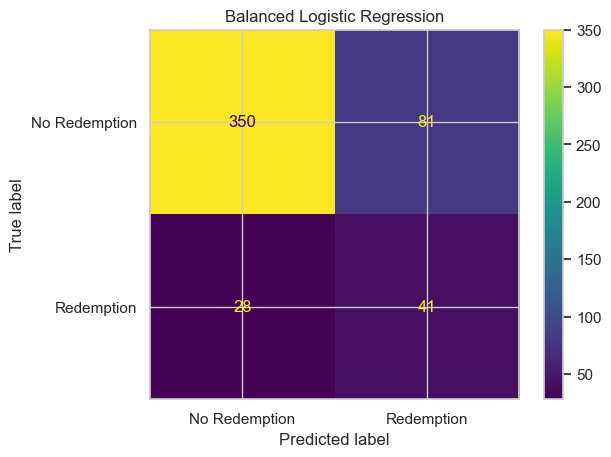

In [73]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_balanced)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Redemption', 'Redemption']
)

disp.plot()
plt.title('Balanced Logistic Regression')
plt.show()

350 true negatives: Correctly predicted that these households wouldn't redeem coupons. \
81 false positives: Predicted redemption, but these households didn't redeem. \
28 false negatives: Missed households that actually redeemed coupons. \
41 true positives: Correctly identified households that redeemed coupons.

#### 6.6 Compare Models

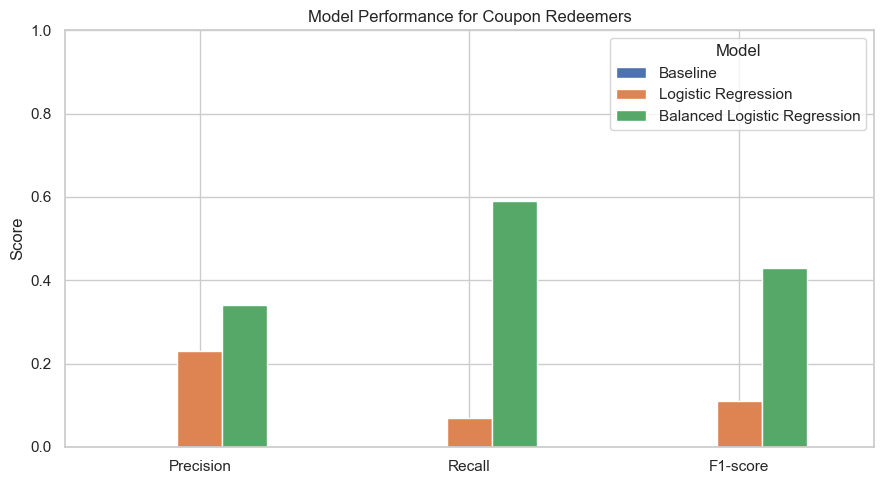

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

model_comparison = pd.DataFrame({
    'Baseline': [0, 0, 0],
    'Logistic Regression': [0.23, 0.07, 0.11],
    'Balanced Logistic Regression': [0.34, 0.59, 0.43]
}, index=['Precision', 'Recall', 'F1-score'])

model_comparison.plot(kind='bar', figsize=(9, 5))

plt.title('Model Performance for Coupon Redeemers')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

Regular Logistic Regression: Higher accuracy, but very low recall (7%). \
Balanced Logistic Regression: Lower accuracy (78%), but much higher recall (59%) and F1-score (43%). \
Baseline: All scores for coupon redeemers are zero, so its bars aren't visible.

#### 6.7 Evaluate ROC-AUC

In [75]:
from sklearn.metrics import roc_auc_score

baseline_auc = roc_auc_score(
    y_test,
    baseline_model.predict_proba(X_test)[:, 1]
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_model.predict_proba(X_test)[:, 1]
)

balanced_auc = roc_auc_score(
    y_test,
    logistic_balanced.predict_proba(X_test)[:, 1]
)

print("Baseline ROC-AUC:", baseline_auc)
print("Logistic Regression ROC-AUC:", logistic_auc)
print("Balanced Logistic Regression ROC-AUC:", balanced_auc)

Baseline ROC-AUC: 0.5
Logistic Regression ROC-AUC: 0.794276875483372
Balanced Logistic Regression ROC-AUC: 0.8110561888429335


Baseline (0.500): Equivalent to random ranking. Since it predicts the same class for everyone, it cannot distinguish between the two groups. \
Logistic Regression (0.794): Shows good separation between the two groups. \
Balanced Logistic Regression (0.811): Has a slightly higher ROC-AUC than the regular model.

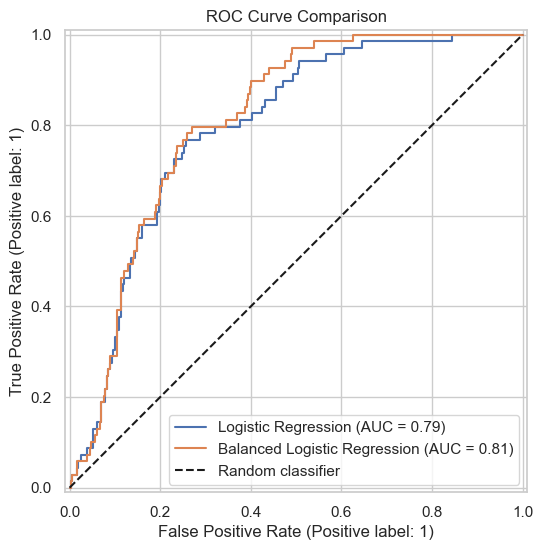

In [76]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(
    logistic_model, X_test, y_test,
    name='Logistic Regression',
    ax=ax
)

RocCurveDisplay.from_estimator(
    logistic_balanced, X_test, y_test,
    name='Balanced Logistic Regression',
    ax=ax
)

ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')

ax.set_title('ROC Curve Comparison')
ax.legend()
plt.show()

ROC Curve Analysis

The ROC curve shows that both Logistic Regression models performed better than random classification, with ROC-AUC scores of 0.79 for the standard model and 0.81 for the balanced model. The balanced Logistic Regression model achieved a slightly higher ROC-AUC, indicating a modest improvement in its ability to distinguish between households that redeemed coupons and those that did not. Both curves remain above the diagonal reference line, suggesting that the models learned meaningful patterns from the customer behavior data. However, the difference in ROC-AUC between the two models is small. Combined with the higher recall of the balanced model, these results suggest that class weighting helped identify more potential coupon redeemers.

## 7.0 Feature Importance
#### 7.1 Identifying the most influential features

In [77]:
coefficients = pd.Series(
    logistic_balanced.named_steps['model'].coef_[0],
    index=X_train.columns
)

coefficients = coefficients.sort_values()

print("Most negative features:")
print(coefficients.head(10))

print("\nMost positive features:")
print(coefficients.tail(10).sort_values(ascending=False))

Most negative features:
Avg_Basket_Value   -0.663343
CNTRL/STORE SUP    -0.486314
HBC                -0.449932
MEAT-PCKGD         -0.357422
FLORAL             -0.232280
VIDEO RENTAL       -0.184809
PROD-WHS SALES     -0.177030
PHARMACY SUPPLY    -0.154313
TRAVEL & LEISUR    -0.116332
SPIRITS            -0.110703
dtype: float64

Most positive features:
GROCERY                    0.794076
Avg_Quantity_Per_Basket    0.773857
Total_Spending             0.446930
PRODUCE                    0.320003
MISC SALES TRAN            0.231014
MEAT                       0.186758
COUP/STR & MFG             0.138103
GM MERCH EXP               0.133234
Shopping_Frequency         0.125363
CHARITABLE CONT            0.091227
dtype: float64


Feature Importance Analysis

The balanced Logistic Regression model identified grocery spending and average quantity per basket as the features with the largest positive coefficients. Total spending and produce spending also showed positive associations with future coupon redemption. In contrast, average basket value, CNTRL/STORE SUP, and HBC had the largest negative coefficients. These results suggest that customer purchasing patterns and product department spending may provide useful information for predicting future coupon redemption. However, the coefficients represent associations within the model and should not be interpreted as causal relationships.

#### 7.2 Visualizing the coefficients

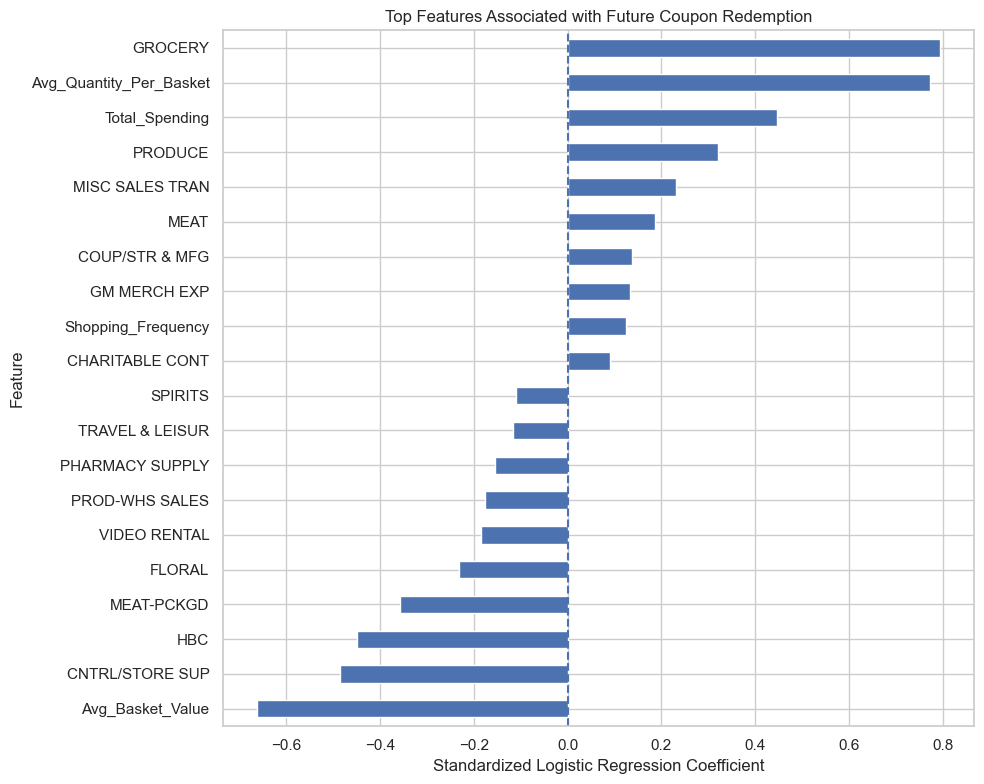

In [78]:
top_features = pd.concat([
    coefficients.head(10),
    coefficients.tail(10)
]).sort_values()

top_features.plot(kind='barh', figsize=(10, 8))

plt.title('Top Features Associated with Future Coupon Redemption')
plt.xlabel('Standardized Logistic Regression Coefficient')
plt.ylabel('Feature')
plt.axvline(x=0, linestyle='--')
plt.tight_layout()
plt.show()

Feature Coefficient Analysis

The feature coefficient analysis identified grocery spending (0.794) and average quantity per basket (0.774) as the strongest positive predictors of future coupon redemption in the balanced Logistic Regression model. Total spending (0.447) and produce spending (0.320) also had positive coefficients. In contrast, average basket value (-0.663), CNTRL/STORE SUP (-0.486), and HBC (-0.450) had the strongest negative coefficients.

These findings suggest that household purchasing patterns and spending across product departments contain useful information for predicting future coupon redemption. However, the coefficients represent associations within the model and do not establish causal relationships.

## Explore : Changing prediction thresholds for comparison....

Findings -> Limitations -> Business Recommendations